# 04 — Evaluation: Quantifying Synthetic Data Fidelity

## Objective
Load the aggregated OLS metrics from `aggregated_model_metrics.parquet` and compute
three evaluation measures for every (method × var_type × N × p × ρ × σ² × iter) scenario:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Coefficient Euclidean Distance** | $\sqrt{\sum_j (\hat{\beta}_{OD,j} - \hat{\beta}_{SD,j})^2}$ | How far the SD coefficients are from the OD coefficients |
| **Significance Agreement** | % of variables where OD & SD agree on $p < 0.05$ | Preservation of inferential conclusions |
| **$R^2$ Degradation** | $|R^2_{adj,OD} - R^2_{adj,SD}|$ | Loss of explanatory power |

## Visualisations (publication-ready, 300 DPI)
1. **Plot 1 — Core Thesis Discovery**: Coefficient Euclidean Distance by method × var_type
2. **Plot 2 — Impact of N and p**: $R^2$ degradation across sample size and dimensionality
3. **Plot 3 — Multicollinearity (ρ)**: Error rates vs. correlation level

In [1]:
# ── Imports & Config ─────────────────────────────────────────────────────────
import os, gc, json, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

# ── Load simulation config (single source of truth) ─────────────────────────
config_path = os.path.join("..", "config", "config.json")
with open(config_path) as f:
    config = json.load(f)

N_VALS      = sorted(config["simulation"]["N"])
P_VALS      = sorted(config["simulation"]["p"])
VAR_TYPES   = sorted(config["simulation"]["var_type"])          # e.g. ["binary", "continuous"]
METHODS     = sorted(config["synthesis"]["methods"])             # e.g. ["cart", "norm", "pmm"]
RHO_VALS    = sorted([float(r) for r in config["parameters"]["rho"]])
SIGMA2_VALS = sorted([float(s) for s in config["parameters"]["sigma_2"]])
BETA_TRUE   = config["parameters"]["beta"]

# ── Publication-quality style ─────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
})

# ── Auto-scaling colour palettes ─────────────────────────────────────────────
# Fixed colours for known keys; auto-extends for new ones via a broad palette.
_FIXED_METHOD_COLORS = {"cart": "#e74c3c", "norm": "#2ecc71", "pmm": "#3498db"}
_FIXED_VTYPE_COLORS  = {"binary": "#3498db", "continuous": "#e74c3c"}
_EXTRA_COLORS = ["#f39c12", "#9b59b6", "#1abc9c", "#e67e22", "#34495e", "#e91e63", "#00bcd4", "#8bc34a"]

def _build_palette(keys, fixed_map, extra_pool):
    """Assign fixed colours to known keys, auto-extend for new ones."""
    palette, extra_idx = {}, 0
    for k in keys:
        if k in fixed_map:
            palette[k] = fixed_map[k]
        else:
            palette[k] = extra_pool[extra_idx % len(extra_pool)]
            extra_idx += 1
    return palette

METHOD_PALETTE = {k.upper(): v for k, v in _build_palette(METHODS, _FIXED_METHOD_COLORS, _EXTRA_COLORS).items()}
METHOD_ORDER   = [m.upper() for m in METHODS]

VARTYPE_PALETTE = {k.capitalize(): v for k, v in _build_palette(VAR_TYPES, _FIXED_VTYPE_COLORS, _EXTRA_COLORS).items()}
VARTYPE_ORDER   = [v.capitalize() for v in VAR_TYPES]

result_dir = os.path.join("..", "results")
fig_dir    = os.path.join(result_dir, "figures")
os.makedirs(fig_dir, exist_ok=True)

print(f"Config loaded — {len(METHODS)} methods × {len(VAR_TYPES)} var_types")
print(f"  N:      {N_VALS}")
print(f"  p:      {P_VALS}")
print(f"  ρ:      {RHO_VALS}")
print(f"  σ²:     {SIGMA2_VALS}")
print(f"  Methods:   {METHOD_ORDER}")
print(f"  Var types: {VARTYPE_ORDER}")
print("Ready.")

Config loaded — 3 methods × 2 var_types
  N:      [100, 1000]
  p:      [2, 5, 10]
  ρ:      [0.0, 0.3, 0.6]
  σ²:     [1.0, 1.5, 2.0]
  Methods:   ['CART', 'NORM', 'PMM']
  Var types: ['Binary', 'Continuous']
Ready.


In [2]:
# ── Load Parquet ─────────────────────────────────────────────────────────────
parquet_path = os.path.join(result_dir, "aggregated_model_metrics.parquet")
df = pd.read_parquet(parquet_path)
print(f"Loaded {len(df):,} rows × {len(df.columns)} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# ── Fix float precision: R writes 0.3 as 0.2999999... in parquet ────────────
# Round to 6 dp so pivot-table index lookups match the config values exactly.
df["rho"]     = df["rho"].round(6)
df["sigma_2"] = df["sigma_2"].round(6)

# Re-derive axis values from actual data (overrides config-based lists)
RHO_VALS    = sorted(df["rho"].dropna().unique())
SIGMA2_VALS = sorted(df["sigma_2"].dropna().unique())
print(f"Unique ρ in data:   {RHO_VALS}")
print(f"Unique σ² in data:  {SIGMA2_VALS}")
df.head(2)

Loaded 324,000 rows × 75 columns
Memory: 198.2 MB
Unique ρ in data:   [np.float64(0.0), np.float64(0.3), np.float64(0.6)]
Unique σ² in data:  [np.float64(1.0), np.float64(1.5), np.float64(2.0)]


,method,var_type,N,p,rho,sigma_2,iter,adj_r2_od,adj_r2_sd,beta_od_0,...,pval_sd_1,pval_sd_2,pval_sd_3,pval_sd_4,pval_sd_5,pval_sd_6,pval_sd_7,pval_sd_8,pval_sd_9,pval_sd_10
0,cart,binary,100,10,0.0,1.0,1,0.654542,0.401856,1.050141,...,4.545434e-07,1.834330e-01,2.691405e-08,0.569402,0.492546,0.865182,0.395269,0.450263,0.017294,0.010363
1,cart,binary,100,10,0.0,1.0,2,0.672864,0.438661,0.894813,...,6.952314e-03,4.819329e-09,4.615538e-01,0.243607,0.479639,0.717727,0.030438,0.432882,0.322539,0.001029


---

## Plot 6 — CI Overlap: OD vs SD Confidence Interval Agreement

**Research question:** How much do the 95 % confidence intervals of the original
and synthetic models actually overlap?

For each slope predictor $j \geq 1$, let $[L_{OD,j}, U_{OD,j}]$ and $[L_{SD,j}, U_{SD,j}]$ be the 95 % CIs.

**Intersection length:**
$$L_{\text{inter},j} = \max\!\left(0,\; \min(U_{OD,j}, U_{SD,j}) - \max(L_{OD,j}, L_{SD,j})\right)$$

**Interval widths:**
$W_{OD,j} = U_{OD,j} - L_{OD,j}$, $\quad W_{SD,j} = U_{SD,j} - L_{SD,j}$

**Average Normalized Overlap:**
$$\text{CI Overlap \%}_j = \frac{1}{2}\left(\frac{L_{\text{inter},j}}{W_{OD,j}} + \frac{L_{\text{inter},j}}{W_{SD,j}}\right) \times 100$$

A value of 100 % indicates identical confidence intervals; 0 % means the
CIs are disjoint. A line plot by $\rho$ reveals how multicollinearity erodes overlap.

In [3]:
# ── Identify coefficient columns (numerical sort to avoid 10 < 2 issue) ──────
_num_key = lambda c: int(c.rsplit("_", 1)[-1])

beta_od_cols = sorted([c for c in df.columns if c.startswith("beta_od_")], key=_num_key)
beta_sd_cols = sorted([c for c in df.columns if c.startswith("beta_sd_")], key=_num_key)
pval_od_cols = sorted([c for c in df.columns if c.startswith("pval_od_")], key=_num_key)
pval_sd_cols = sorted([c for c in df.columns if c.startswith("pval_sd_")], key=_num_key)

print(f"Coefficient columns: {len(beta_od_cols)} (OD) / {len(beta_sd_cols)} (SD)")
print(f"P-value columns:     {len(pval_od_cols)} (OD) / {len(pval_sd_cols)} (SD)")
print(f"  Order check: {beta_od_cols[:3]} … {beta_od_cols[-1]}")

Coefficient columns: 11 (OD) / 11 (SD)
P-value columns:     11 (OD) / 11 (SD)
  Order check: ['beta_od_0', 'beta_od_1', 'beta_od_2'] … beta_od_10


In [4]:
# ── 1. Coefficient Euclidean Distance ───────────────────────────────────────
beta_od_arr = df[beta_od_cols].values  # (n_rows, 11)
beta_sd_arr = df[beta_sd_cols].values

# NaN-aware: np.nansum treats NaN positions (from p=3 padding) as 0 difference
df["coef_eucl_dist"] = np.sqrt(np.nansum((beta_od_arr - beta_sd_arr) ** 2, axis=1))

print("Coefficient Euclidean Distance — summary by method:")
print(df.groupby("method")["coef_eucl_dist"].describe().round(3))

Coefficient Euclidean Distance — summary by method:
           count   mean    std    min    25%    50%    75%     max
method                                                            
cart    108000.0  1.148  1.194  0.003  0.284  0.760  1.478  12.524
norm    108000.0  0.605  0.586  0.004  0.186  0.415  0.820   5.663
pmm     108000.0  0.506  0.492  0.004  0.171  0.339  0.661   7.340


In [5]:
# ── 2. Significance Agreement ───────────────────────────────────────────────
#
# For each row, count how many predictors (excluding intercept at index 0)
# have MATCHING significance decisions at α = 0.05.
#   sig_od_j = (pval_od_j < 0.05)
#   sig_sd_j = (pval_sd_j < 0.05)
#   agreement_j = (sig_od_j == sig_sd_j)
#   significance_agreement = mean(agreement_j) * 100

# Use only slope p-values (indices 1..p), skip intercept
pval_od_arr = df[pval_od_cols[1:]].values  # skip pval_od_0 (intercept)
pval_sd_arr = df[pval_sd_cols[1:]].values

sig_od = pval_od_arr < 0.05
sig_sd = pval_sd_arr < 0.05

# Where both are NaN (padding for p=3), that's not a real predictor — mask it
valid_mask = ~(np.isnan(pval_od_arr) & np.isnan(pval_sd_arr))
agreement  = (sig_od == sig_sd) & valid_mask

n_valid = valid_mask.sum(axis=1)
n_agree = agreement.sum(axis=1)

df["sig_agreement_pct"] = np.where(n_valid > 0, (n_agree / n_valid) * 100, np.nan)

print("Significance Agreement (%) — summary by method:")
print(df.groupby("method")["sig_agreement_pct"].describe().round(2))

Significance Agreement (%) — summary by method:
           count   mean    std  min    25%    50%    75%    max
method                                                         
cart    108000.0  83.04  25.39  0.0   60.0  100.0  100.0  100.0
norm    108000.0  95.17  12.72  0.0  100.0  100.0  100.0  100.0
pmm     108000.0  94.93  13.06  0.0  100.0  100.0  100.0  100.0


In [6]:
# ── 3. R² Degradation ───────────────────────────────────────────────────────
df["r2_degradation"] = (df["adj_r2_od"] - df["adj_r2_sd"]).abs()

print("R² Degradation — summary by method:")
print(df.groupby("method")["r2_degradation"].describe().round(4))

R² Degradation — summary by method:
           count    mean     std  min     25%     50%     75%     max
method                                                               
cart    108000.0  0.1355  0.1417  0.0  0.0309  0.0855  0.1967  0.9050
norm    108000.0  0.0335  0.0396  0.0  0.0070  0.0204  0.0438  0.4294
pmm     108000.0  0.0307  0.0402  0.0  0.0055  0.0158  0.0389  0.5684


In [7]:
# ── Save enriched DataFrame ─────────────────────────────────────────────────
enriched_path = os.path.join(result_dir, "evaluation_metrics.parquet")
df.to_parquet(enriched_path, index=False)
print(f"✓ Saved enriched metrics to: {enriched_path}")
print(f"  Columns added: coef_eucl_dist, sig_agreement_pct, r2_degradation")

# Free memory from large arrays
del beta_od_arr, beta_sd_arr, pval_od_arr, pval_sd_arr, sig_od, sig_sd
gc.collect()

df.head(3)

✓ Saved enriched metrics to: ../results/evaluation_metrics.parquet
  Columns added: coef_eucl_dist, sig_agreement_pct, r2_degradation


,method,var_type,N,p,rho,sigma_2,iter,adj_r2_od,adj_r2_sd,beta_od_0,...,pval_sd_4,pval_sd_5,pval_sd_6,pval_sd_7,pval_sd_8,pval_sd_9,pval_sd_10,coef_eucl_dist,sig_agreement_pct,r2_degradation
0,cart,binary,100,10,0.0,1.0,1,0.654542,0.401856,1.050141,...,0.569402,0.492546,0.865182,3.952689e-01,0.450263,1.729377e-02,0.010363,2.611389,40.0,0.252686
1,cart,binary,100,10,0.0,1.0,2,0.672864,0.438661,0.894813,...,0.243607,0.479639,0.717727,3.043829e-02,0.432882,3.225386e-01,0.001029,3.439890,40.0,0.234203
2,cart,binary,100,10,0.0,1.0,3,0.801024,0.565508,0.782426,...,0.006862,0.157603,0.397464,5.986886e-08,0.263882,2.717605e-07,0.820394,3.021786,40.0,0.235516


---

## Plot 1 — Core Thesis Discovery

**Research question:** Does CART fail to preserve regression coefficients for
continuous predictors while performing well for binary predictors?

A grouped boxplot of **Coefficient Euclidean Distance** across the 3 synthesis
methods, faceted by `var_type`, directly tests this hypothesis.  
If CART's distribution is dramatically higher for `continuous` but comparable to
NORM / PMM for `binary`, the thesis finding is confirmed.

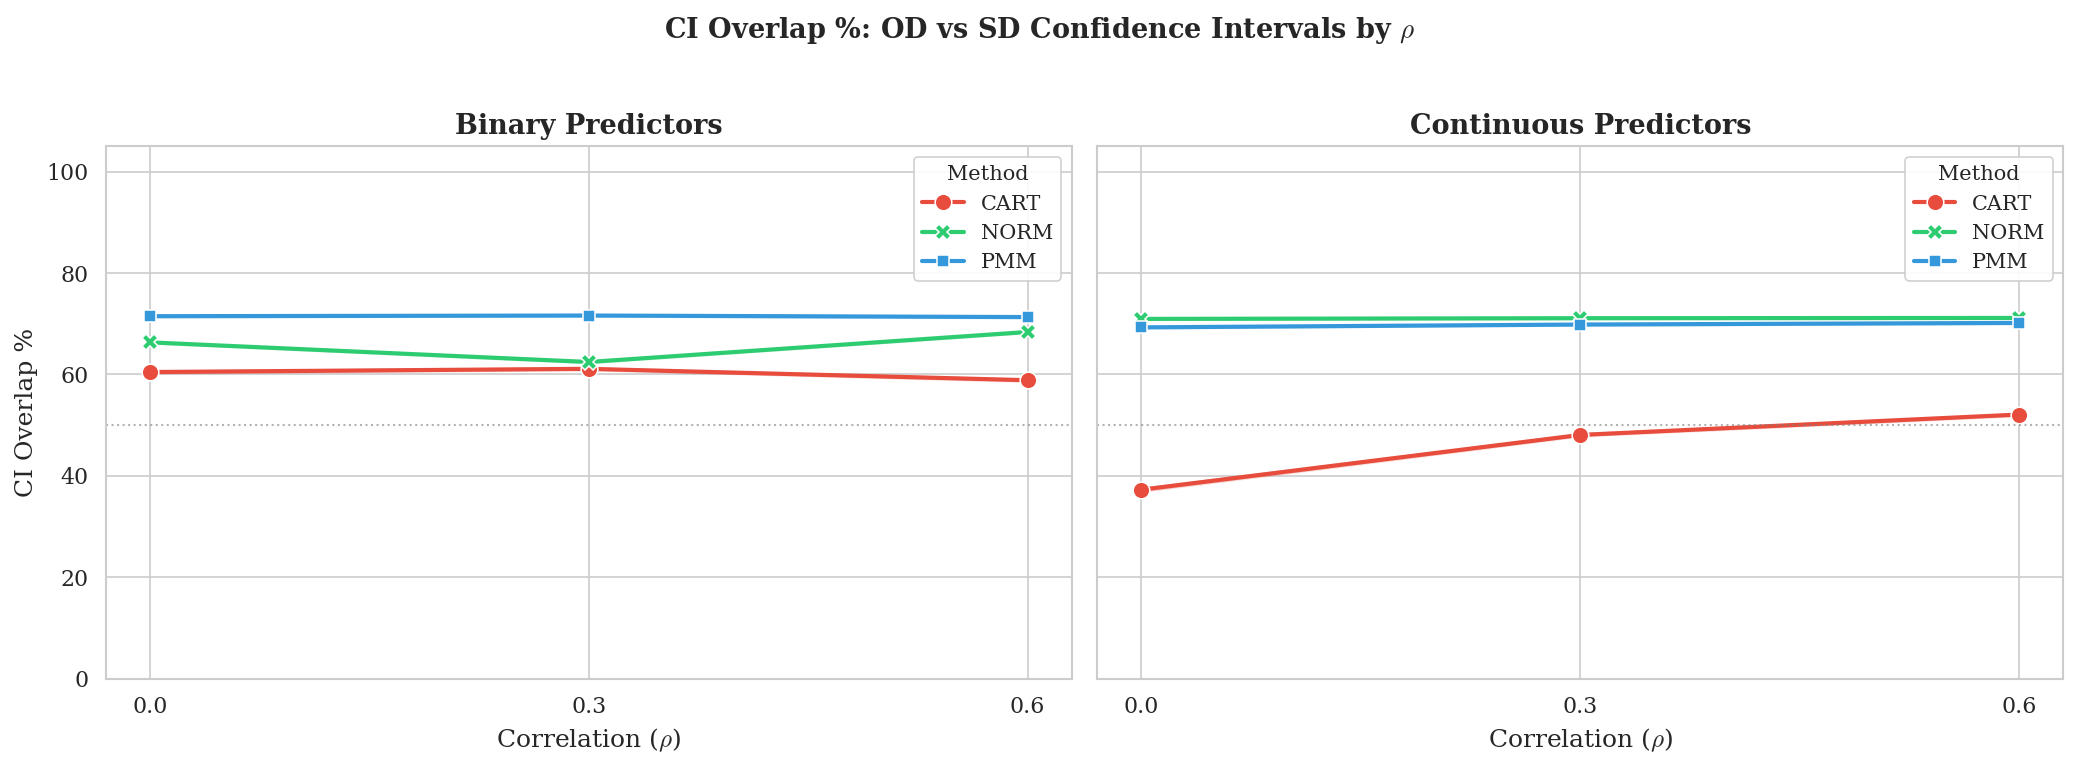

✓ Plot 6 saved.


2465

In [8]:
# ── Plot 6: CI Overlap % (OD vs SD) by Method × var_type ─────────────────────
#
# Compute the overlap percentage between OD and SD 95 % CIs for every slope
# predictor, then average across predictors per row.
# Formula: CI_Overlap = 0.5 * (L_inter / W_orig + L_inter / W_syn) * 100

beta_od_slope_cols = sorted(
    [c for c in df.columns if c.startswith("beta_od_") and c != "beta_od_0"],
    key=lambda c: int(c.rsplit("_", 1)[-1]),
)
beta_sd_slope_cols = sorted(
    [c for c in df.columns if c.startswith("beta_sd_") and c != "beta_sd_0"],
    key=lambda c: int(c.rsplit("_", 1)[-1]),
)
se_od_slope_cols = sorted(
    [c for c in df.columns if c.startswith("se_od_") and c != "se_od_0"],
    key=lambda c: int(c.rsplit("_", 1)[-1]),
)
se_sd_slope_cols = sorted(
    [c for c in df.columns if c.startswith("se_sd_") and c != "se_sd_0"],
    key=lambda c: int(c.rsplit("_", 1)[-1]),
)

bo = df[beta_od_slope_cols].values
bs = df[beta_sd_slope_cols].values
so = df[se_od_slope_cols].values
ss = df[se_sd_slope_cols].values

# 95 % CI bounds
L_od = bo - 1.96 * so
U_od = bo + 1.96 * so
L_sd = bs - 1.96 * ss
U_sd = bs + 1.96 * ss

# Intersection length
L_inter = np.maximum(0, np.minimum(U_od, U_sd) - np.maximum(L_od, L_sd))

# Individual interval widths
W_orig = U_od - L_od
W_syn  = U_sd - L_sd

valid = (
    ~np.isnan(bo) & ~np.isnan(bs) &
    ~np.isnan(so) & ~np.isnan(ss) &
    (so > 0) & (ss > 0) & (W_orig > 0) & (W_syn > 0)
)

with np.errstate(divide="ignore", invalid="ignore"):
    ci_pct = np.where(valid, 0.5 * (L_inter / W_orig + L_inter / W_syn) * 100, np.nan)

df["ci_overlap_pct"] = np.nanmean(ci_pct, axis=1)

# ── Plot ─────────────────────────────────────────────────────────────────────
cov_df = df.dropna(subset=["ci_overlap_pct"]).copy()
cov_df["Method"]        = cov_df["method"].str.upper()
cov_df["Variable Type"] = cov_df["var_type"].str.capitalize()

n_vtypes = len(VARTYPE_ORDER)
fig, axes = plt.subplots(1, n_vtypes, figsize=(7 * n_vtypes, 5), sharey=True, squeeze=False)
axes = axes.ravel()

for ax, vt in zip(axes, VARTYPE_ORDER):
    subset_cov = cov_df[cov_df["Variable Type"] == vt]
    sns.lineplot(
        data=subset_cov,
        x="rho",
        y="ci_overlap_pct",
        hue="Method",
        hue_order=METHOD_ORDER,
        palette=METHOD_PALETTE,
        style="Method",
        markers=True,
        dashes=False,
        errorbar=("ci", 95),
        linewidth=2,
        markersize=8,
        ax=ax,
    )
    ax.axhline(50, color="gray", linestyle=":", linewidth=1, alpha=0.6)
    ax.set_ylim(0, 105)
    ax.set_xlabel(r"Correlation ($\rho$)", fontsize=12)
    ax.set_ylabel("CI Overlap %" if ax == axes[0] else "", fontsize=12)
    ax.set_title(f"{vt} Predictors", fontsize=13, fontweight="bold")
    ax.set_xticks(RHO_VALS)
    ax.legend(title="Method", fontsize=10, title_fontsize=10, framealpha=0.9)

fig.suptitle(
    r"CI Overlap %: OD vs SD Confidence Intervals by $\rho$",
    fontsize=13, fontweight="bold", y=1.02,
)

plt.tight_layout()
fig.savefig(os.path.join(fig_dir, "plot6_ci_overlap.png"))
plt.show()
print("✓ Plot 6 saved.")

# Clean up large intermediates
del L_od, U_od, L_sd, U_sd, L_inter, W_orig, W_syn, ci_pct
gc.collect()

---

## Plot 2 — Impact of Sample Size (N) and Dimensionality (p)

**Research question:** How does $R^2$ degradation behave when $N$ and $p$ change?

A 2×2 facet grid (rows = $N$, columns = $p$) with grouped boxplots by method
shows whether:
- Larger $N$ reduces degradation (more data → better synthesis)
- Higher $p$ increases degradation (curse of dimensionality for synthesis)

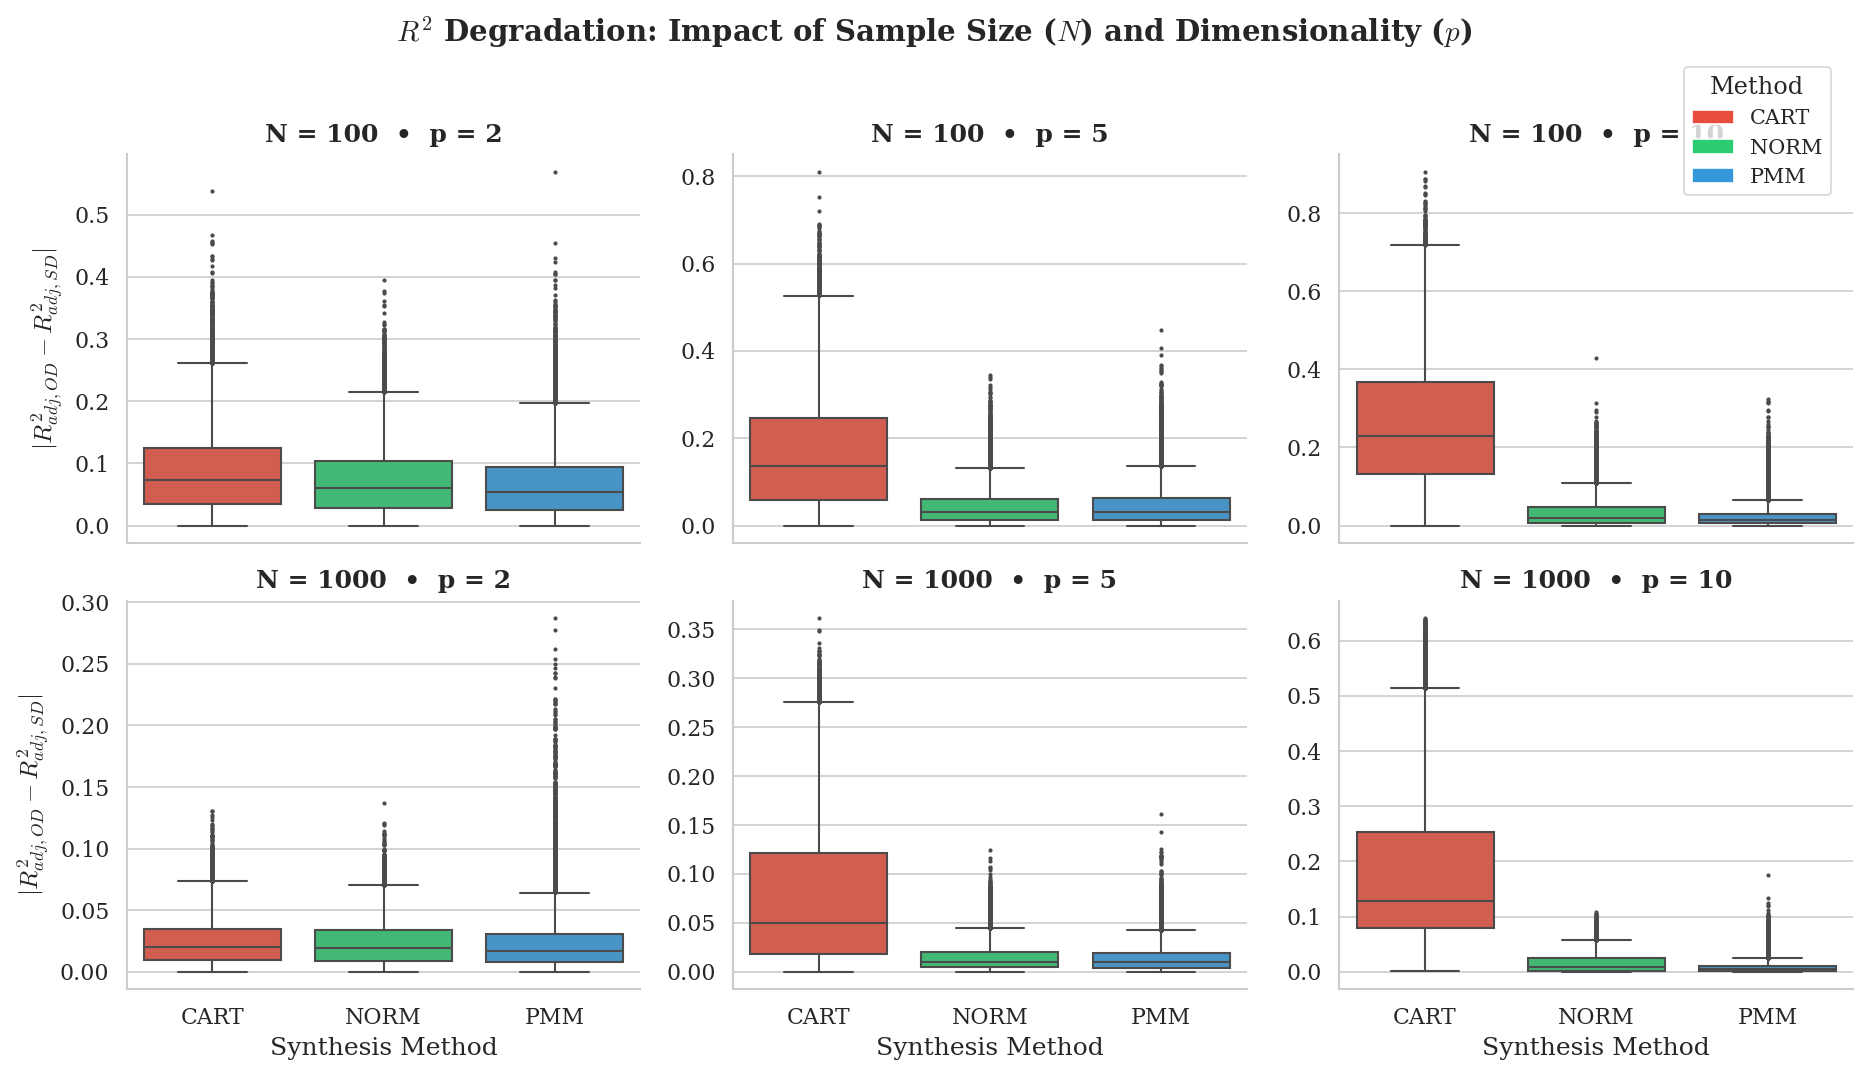

✓ Plot 2 saved.


In [9]:
# ── Plot 2: R² Degradation by N × p (facet grid) ───────────────────────────

plot_df2 = df.dropna(subset=["r2_degradation"]).copy()
plot_df2["Method"] = plot_df2["method"].str.upper()
plot_df2["N_label"] = "N = " + plot_df2["N"].astype(str)
plot_df2["p_label"] = "p = " + plot_df2["p"].astype(str)

N_label_order = [f"N = {n}" for n in N_VALS]
p_label_order = [f"p = {p}" for p in P_VALS]

g = sns.catplot(
    data=plot_df2,
    x="Method",
    y="r2_degradation",
    hue="Method",
    col="p_label",
    row="N_label",
    kind="box",
    order=METHOD_ORDER,
    hue_order=METHOD_ORDER,
    palette=METHOD_PALETTE,
    col_order=p_label_order,
    row_order=N_label_order,
    height=3.5,
    aspect=1.2,
    fliersize=1,
    linewidth=1,
    legend=False,
    sharey=False,
)

g.figure.suptitle(r"$R^2$ Degradation: Impact of Sample Size ($N$) and Dimensionality ($p$)",
                  fontsize=14, fontweight="bold", y=1.02)
g.set_axis_labels("Synthesis Method", r"$|R^2_{adj,OD} - R^2_{adj,SD}|$")
g.set_titles("{row_name}  •  {col_name}")

legend_elements = [Patch(facecolor=METHOD_PALETTE[m], label=m) for m in METHOD_ORDER]
g.figure.legend(handles=legend_elements, loc="upper right",
                bbox_to_anchor=(0.98, 0.98), fontsize=10, title="Method")

plt.tight_layout()
g.savefig(os.path.join(fig_dir, "plot2_r2_degradation_N_p.png"))
plt.show()
print("✓ Plot 2 saved.")

---

## Plot 3 — Effect of Multicollinearity (ρ)

**Research question:** How does increasing predictor correlation ($\rho$) affect
each synthesis method's ability to preserve regression coefficients?

A line plot with $\rho$ on the x-axis and **mean Coefficient Euclidean Distance**
on the y-axis, with one line per method.  
Error bands show the 95% CI of the mean across simulation repetitions.

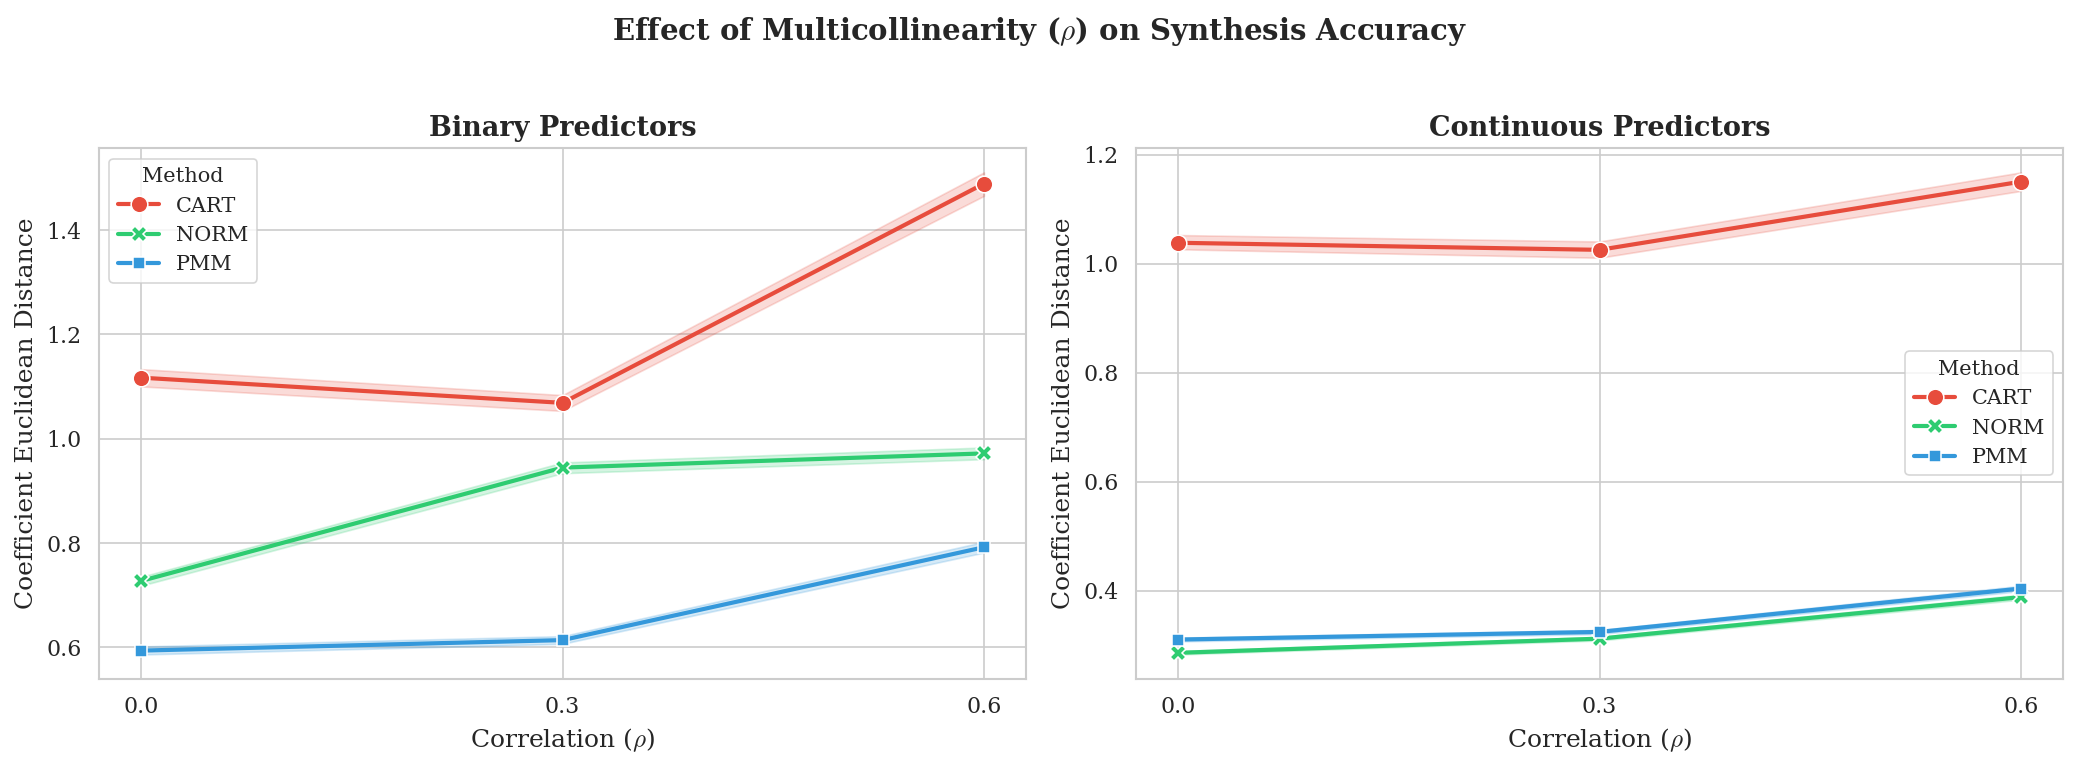

✓ Plot 3 saved.


In [10]:
# ── Plot 3: Coefficient Distance vs. ρ (multicollinearity) ──────────────────

plot_df3 = df.dropna(subset=["coef_eucl_dist"]).copy()
plot_df3["Method"] = plot_df3["method"].str.upper()
plot_df3["Variable Type"] = plot_df3["var_type"].str.capitalize()

n_vtypes = len(VARTYPE_ORDER)
fig, axes = plt.subplots(1, n_vtypes, figsize=(7 * n_vtypes, 5), sharey=False, squeeze=False)
axes = axes.ravel()

for ax, vtype in zip(axes, VARTYPE_ORDER):
    subset = plot_df3[plot_df3["Variable Type"] == vtype]
    
    sns.lineplot(
        data=subset,
        x="rho",
        y="coef_eucl_dist",
        hue="Method",
        hue_order=METHOD_ORDER,
        palette=METHOD_PALETTE,
        style="Method",
        markers=True,
        dashes=False,
        errorbar=("ci", 95),
        linewidth=2,
        markersize=8,
        ax=ax,
    )
    
    ax.set_title(f"{vtype} Predictors", fontsize=13, fontweight="bold")
    ax.set_xlabel(r"Correlation ($\rho$)", fontsize=12)
    ax.set_ylabel(r"Coefficient Euclidean Distance", fontsize=12)
    ax.set_xticks(RHO_VALS)
    ax.legend(title="Method", fontsize=10, title_fontsize=10)

fig.suptitle(r"Effect of Multicollinearity ($\rho$) on Synthesis Accuracy",
             fontsize=14, fontweight="bold", y=1.02)

plt.tight_layout()
fig.savefig(os.path.join(fig_dir, "plot3_multicollinearity_rho.png"))
plt.show()
print("✓ Plot 3 saved.")

---

## Plot 4 — Practical Utility: Significance Agreement Rate

**Research question:** If a researcher uses synthetic data to run inference, will they
draw the same statistical conclusions about which predictors are significant?

A grouped bar chart of the **Significance Agreement Rate** (%) by method, faceted
by `var_type`, reveals whether the synthesis preserves inferential validity.
A dashed reference line at 100 % marks perfect agreement.


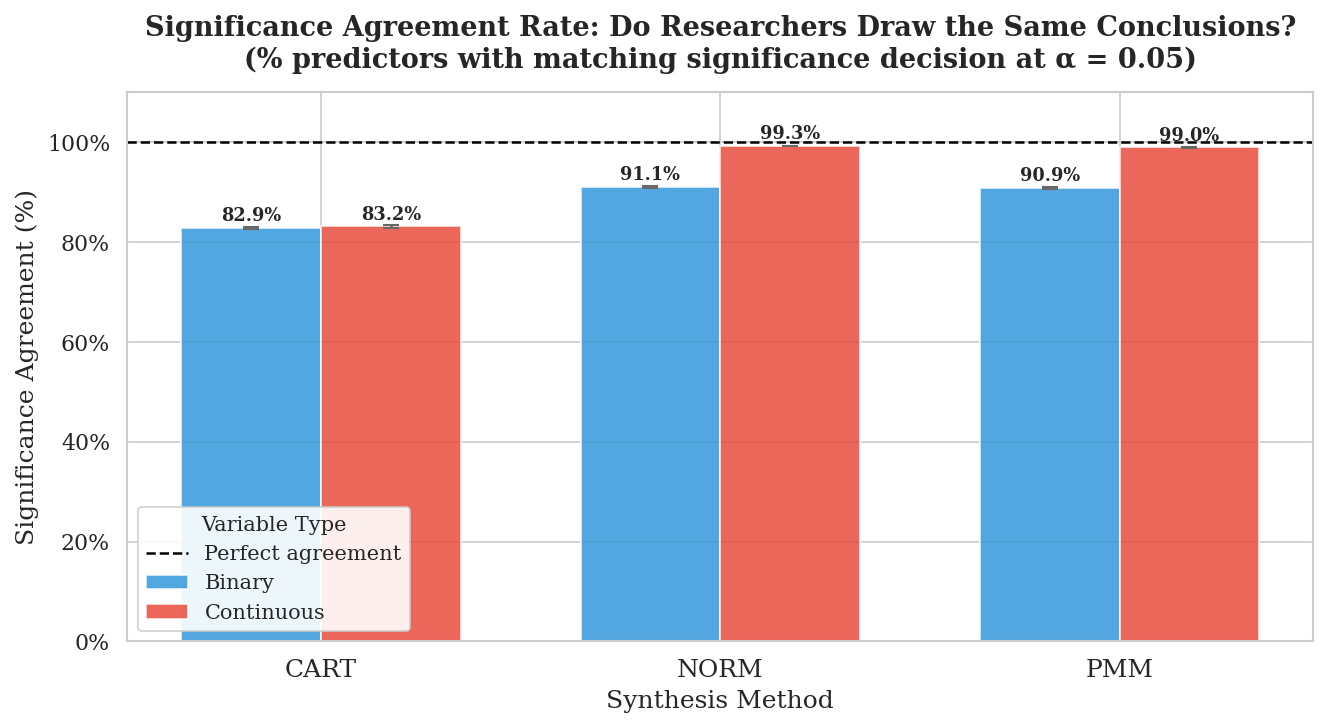

✓ Plot 4 saved.


In [11]:
# ── Plot 4: Significance Agreement Rate by Method × var_type ────────────────

plot_df4 = df.dropna(subset=["sig_agreement_pct"]).copy()
plot_df4["Method"] = plot_df4["method"].str.upper()
plot_df4["Variable Type"] = plot_df4["var_type"].str.capitalize()

# Compute mean ± 95 % CI per (Method, Variable Type)
agg4 = (
    plot_df4.groupby(["Method", "Variable Type"])["sig_agreement_pct"]
    .agg(mean="mean", std="std", count="count")
    .reset_index()
)
agg4["ci95"] = 1.96 * agg4["std"] / agg4["count"].pow(0.5)

n_vtypes = len(VARTYPE_ORDER)
x        = np.arange(len(METHOD_ORDER))
width    = 0.7 / n_vtypes
offsets  = {vt: (i - (n_vtypes - 1) / 2) * width for i, vt in enumerate(VARTYPE_ORDER)}

fig, ax = plt.subplots(figsize=(max(9, 3 * len(METHOD_ORDER)), 5))

for vt in VARTYPE_ORDER:
    subset_agg = agg4[agg4["Variable Type"] == vt].set_index("Method")
    means  = [subset_agg.loc[m, "mean"] if m in subset_agg.index else 0 for m in METHOD_ORDER]
    cis    = [subset_agg.loc[m, "ci95"] if m in subset_agg.index else 0 for m in METHOD_ORDER]
    bars   = ax.bar(
        x + offsets[vt], means, width,
        label=vt, color=VARTYPE_PALETTE[vt],
        alpha=0.85, edgecolor="white", linewidth=0.8,
        yerr=cis, capsize=4, error_kw=dict(linewidth=1.2, ecolor="dimgray"),
    )
    for bar, mean in zip(bars, means):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.6,
            f"{mean:.1f}%",
            ha="center", va="bottom", fontsize=8.5, fontweight="bold",
        )

ax.axhline(100, color="black", linestyle="--", linewidth=1.2, label="Perfect agreement")
ax.set_xticks(x)
ax.set_xticklabels(METHOD_ORDER, fontsize=12)
ax.set_ylim(0, 110)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=100))
ax.set_xlabel("Synthesis Method", fontsize=12)
ax.set_ylabel("Significance Agreement (%)", fontsize=12)
ax.set_title("Significance Agreement Rate: Do Researchers Draw the Same Conclusions?\n"
             "(% predictors with matching significance decision at α = 0.05)",
             fontsize=13, fontweight="bold", pad=12)
ax.legend(title="Variable Type", fontsize=10, title_fontsize=10, framealpha=0.9)

plt.tight_layout()
fig.savefig(os.path.join(fig_dir, "plot4_significance_agreement.png"))
plt.show()
print("✓ Plot 4 saved.")

---

## Plot 5 — Overconfidence: Standard Error Ratio

**Research question:** Do synthesis methods artificially inflate or deflate the
uncertainty of coefficient estimates?

For each predictor slope $j \geq 1$, the **SE Ratio** is
$$\text{SE Ratio}_j = \frac{SE(\hat{\beta}_{SD,j})}{SE(\hat{\beta}_{OD,j})}$$

A ratio below 1 means the synthetic model is *overconfident*; above 1 means it is
*underconfident*. A bold dashed line at `y = 1.0` marks the ideal.


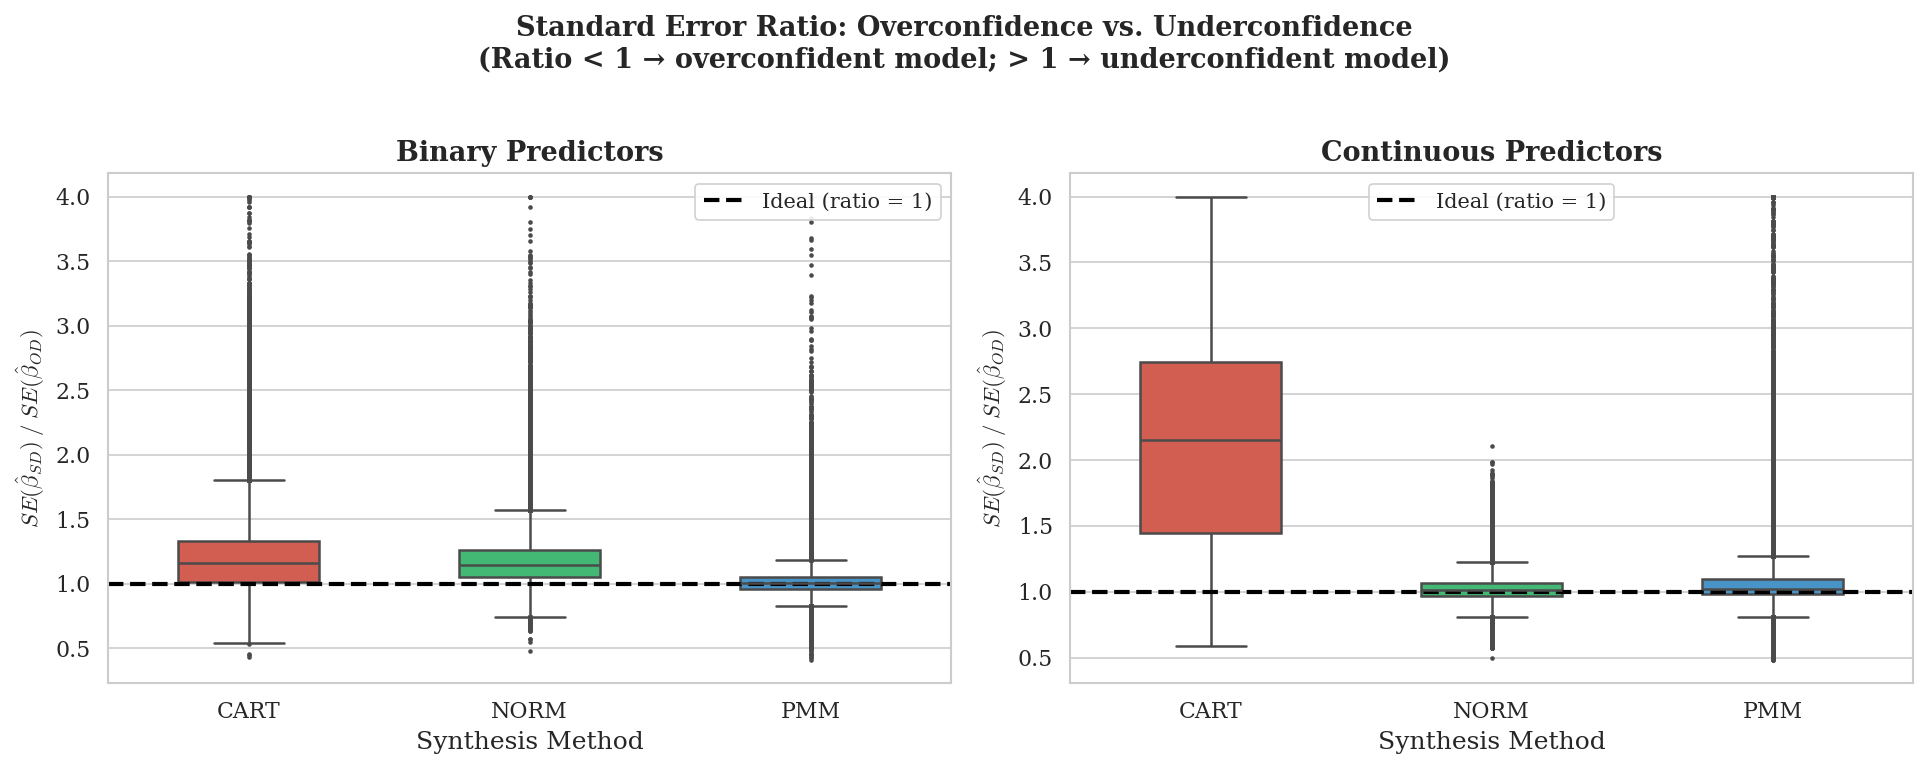

✓ Plot 5 saved.


In [12]:
# ── Plot 5: SE Ratio boxplot by Method × var_type ───────────────────────────

se_od_slope_cols = [c for c in df.columns if c.startswith("se_od_") and c != "se_od_0"]
se_sd_slope_cols = [c for c in df.columns if c.startswith("se_sd_") and c != "se_sd_0"]

se_od_arr = df[se_od_slope_cols].values
se_sd_arr = df[se_sd_slope_cols].values

with np.errstate(divide="ignore", invalid="ignore"):
    se_ratio_arr = np.where(
        (se_od_arr > 0) & ~np.isnan(se_od_arr) & ~np.isnan(se_sd_arr),
        se_sd_arr / se_od_arr,
        np.nan,
    )

n_rows, n_cols = se_ratio_arr.shape
row_idx, col_idx = np.where(~np.isnan(se_ratio_arr))

se_df = pd.DataFrame({
    "se_ratio": se_ratio_arr[row_idx, col_idx],
    "method":   df["method"].values[row_idx],
    "var_type": df["var_type"].values[row_idx],
})
se_df["Method"]        = se_df["method"].str.upper()
se_df["Variable Type"] = se_df["var_type"].str.capitalize()
se_df["se_ratio_capped"] = se_df["se_ratio"].clip(0, 4)

n_vtypes = len(VARTYPE_ORDER)
fig, axes = plt.subplots(1, n_vtypes, figsize=(6.5 * n_vtypes, 5), sharey=False, squeeze=False)
axes = axes.ravel()

for ax, vt in zip(axes, VARTYPE_ORDER):
    subset_se = se_df[se_df["Variable Type"] == vt]
    sns.boxplot(
        data=subset_se,
        x="Method",
        y="se_ratio_capped",
        order=METHOD_ORDER,
        palette=METHOD_PALETTE,
        fliersize=1.2,
        linewidth=1.2,
        width=0.5,
        ax=ax,
    )
    ax.axhline(1.0, color="black", linestyle="--", linewidth=2, label="Ideal (ratio = 1)")
    ax.set_title(f"{vt} Predictors", fontsize=13, fontweight="bold")
    ax.set_xlabel("Synthesis Method", fontsize=12)
    ax.set_ylabel(r"$SE(\hat{\beta}_{SD}) \;/\; SE(\hat{\beta}_{OD})$", fontsize=11)
    ax.legend(fontsize=10, framealpha=0.9)

fig.suptitle("Standard Error Ratio: Overconfidence vs. Underconfidence\n"
             "(Ratio < 1 → overconfident model; > 1 → underconfident model)",
             fontsize=13, fontweight="bold", y=1.02)

plt.tight_layout()
fig.savefig(os.path.join(fig_dir, "plot5_se_ratio.png"))
plt.show()
print("✓ Plot 5 saved.")

---

## Plot 6 — CI Overlap: OD vs SD Confidence Interval Agreement

**Research question:** How much do the 95 % confidence intervals of the original
and synthetic models actually overlap?

For each slope predictor $j \geq 1$:
$$\text{overlap}_j = \max\!\left(0,\; \min(U_{OD,j}, U_{SD,j}) - \max(L_{OD,j}, L_{SD,j})\right)$$
$$\text{CI Overlap \%}_j = \frac{\text{overlap}_j}{\max(U_{OD,j}, U_{SD,j}) - \min(L_{OD,j}, L_{SD,j})} \times 100$$

We always use the **overlap percentage of OD and SD** (Jaccard-style denominator =
union span). A value of 100 % indicates perfect interval agreement; 0 % means the
CIs are disjoint. A line plot by $\rho$ reveals how multicollinearity erodes overlap.

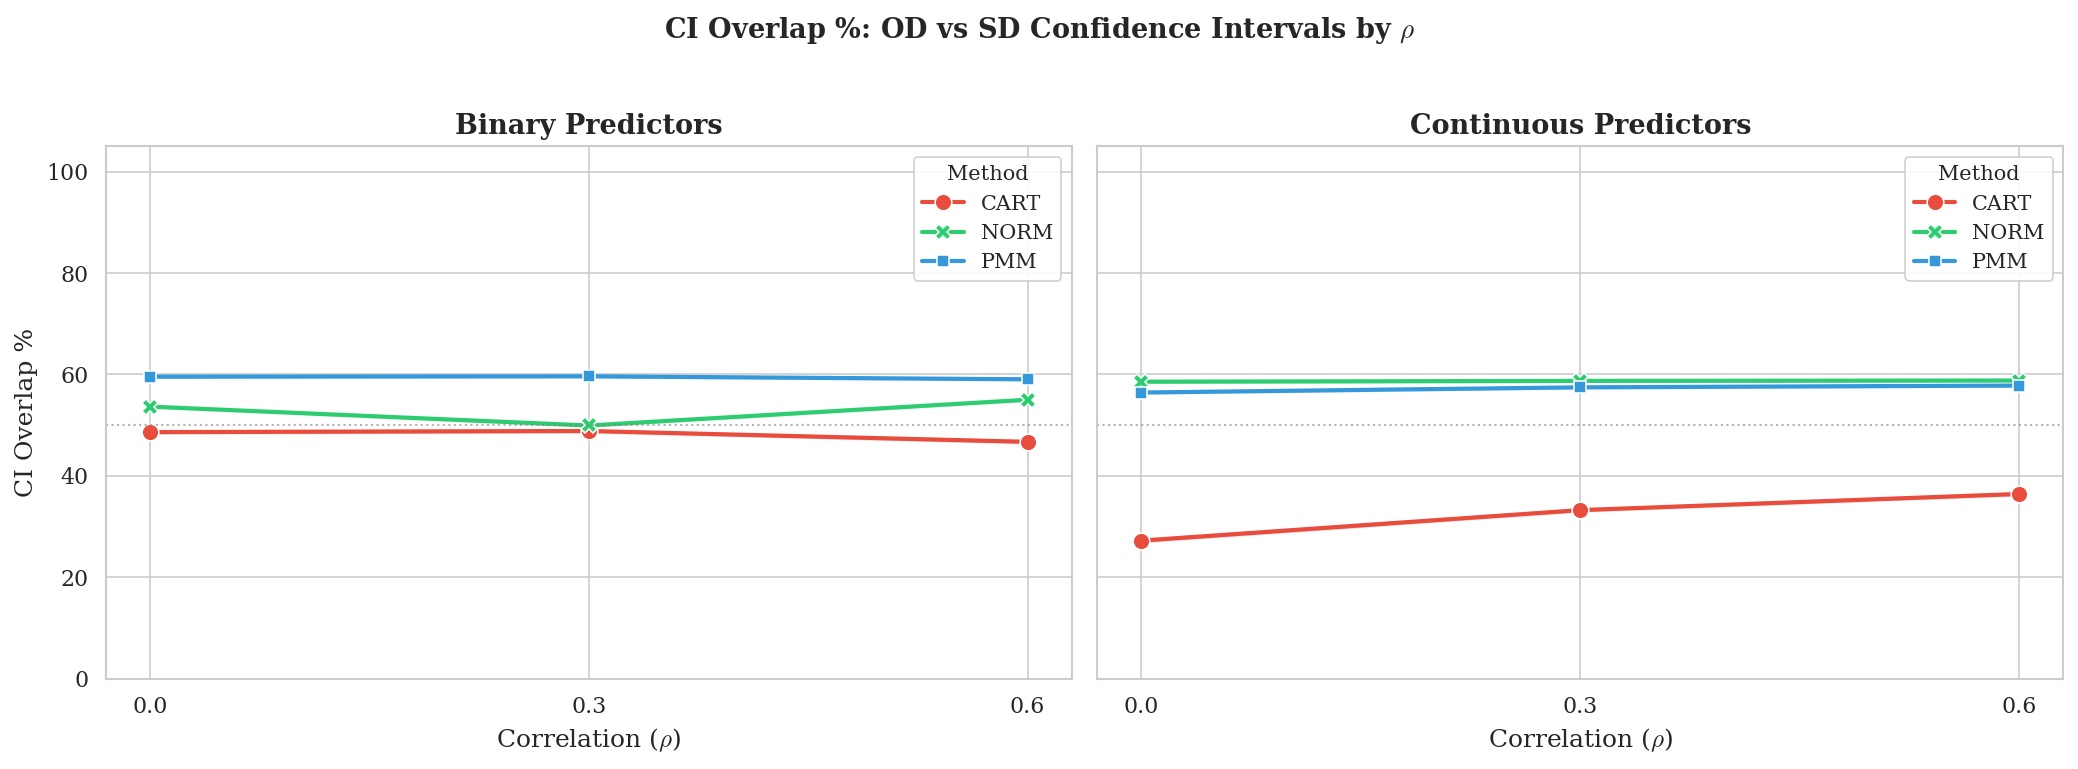

✓ Plot 6 saved.


28511

In [13]:
# ── Plot 6: CI Overlap % (OD vs SD) by Method × var_type ─────────────────────
#
# Compute the overlap percentage between OD and SD 95 % CIs for every slope
# predictor, then average across predictors per row.

beta_od_slope_cols = sorted(
    [c for c in df.columns if c.startswith("beta_od_") and c != "beta_od_0"],
    key=lambda c: int(c.rsplit("_", 1)[-1]),
)
beta_sd_slope_cols = sorted(
    [c for c in df.columns if c.startswith("beta_sd_") and c != "beta_sd_0"],
    key=lambda c: int(c.rsplit("_", 1)[-1]),
)
se_od_slope_cols = sorted(
    [c for c in df.columns if c.startswith("se_od_") and c != "se_od_0"],
    key=lambda c: int(c.rsplit("_", 1)[-1]),
)
se_sd_slope_cols = sorted(
    [c for c in df.columns if c.startswith("se_sd_") and c != "se_sd_0"],
    key=lambda c: int(c.rsplit("_", 1)[-1]),
)

bo = df[beta_od_slope_cols].values
bs = df[beta_sd_slope_cols].values
so = df[se_od_slope_cols].values
ss = df[se_sd_slope_cols].values

# 95 % CI bounds
L_od = bo - 1.96 * so
U_od = bo + 1.96 * so
L_sd = bs - 1.96 * ss
U_sd = bs + 1.96 * ss

# Overlap and union spans
overlap_len = np.maximum(0, np.minimum(U_od, U_sd) - np.maximum(L_od, L_sd))
union_len   = np.maximum(U_od, U_sd) - np.minimum(L_od, L_sd)

valid = (
    ~np.isnan(bo) & ~np.isnan(bs) &
    ~np.isnan(so) & ~np.isnan(ss) &
    (so > 0) & (ss > 0) & (union_len > 0)
)

with np.errstate(divide="ignore", invalid="ignore"):
    ci_pct = np.where(valid, (overlap_len / union_len) * 100, np.nan)

df["ci_overlap_pct"] = np.nanmean(ci_pct, axis=1)

# ── Plot ─────────────────────────────────────────────────────────────────────
cov_df = df.dropna(subset=["ci_overlap_pct"]).copy()
cov_df["Method"]        = cov_df["method"].str.upper()
cov_df["Variable Type"] = cov_df["var_type"].str.capitalize()

n_vtypes = len(VARTYPE_ORDER)
fig, axes = plt.subplots(1, n_vtypes, figsize=(7 * n_vtypes, 5), sharey=True, squeeze=False)
axes = axes.ravel()

for ax, vt in zip(axes, VARTYPE_ORDER):
    subset_cov = cov_df[cov_df["Variable Type"] == vt]
    sns.lineplot(
        data=subset_cov,
        x="rho",
        y="ci_overlap_pct",
        hue="Method",
        hue_order=METHOD_ORDER,
        palette=METHOD_PALETTE,
        style="Method",
        markers=True,
        dashes=False,
        errorbar=("ci", 95),
        linewidth=2,
        markersize=8,
        ax=ax,
    )
    ax.axhline(50, color="gray", linestyle=":", linewidth=1, alpha=0.6)
    ax.set_ylim(0, 105)
    ax.set_xlabel(r"Correlation ($\rho$)", fontsize=12)
    ax.set_ylabel("CI Overlap %" if ax == axes[0] else "", fontsize=12)
    ax.set_title(f"{vt} Predictors", fontsize=13, fontweight="bold")
    ax.set_xticks(RHO_VALS)
    ax.legend(title="Method", fontsize=10, title_fontsize=10, framealpha=0.9)

fig.suptitle(
    r"CI Overlap %: OD vs SD Confidence Intervals by $\rho$",
    fontsize=13, fontweight="bold", y=1.02,
)

plt.tight_layout()
fig.savefig(os.path.join(fig_dir, "plot6_ci_overlap.png"))
plt.show()
print("✓ Plot 6 saved.")

# Clean up large intermediates
del L_od, U_od, L_sd, U_sd, overlap_len, union_len, ci_pct
gc.collect()

---

## Plot 7 — Noise Sensitivity: Impact of Error Variance ($\sigma^2$)

**Research question:** Does increasing the inherent noise in the original data
($\sigma^2 \in \{1.0, 1.5, 2.0\}$) amplify synthesis error, or does the extra
noise mask the structural distortions introduced by CART?

A line plot with $\sigma^2$ on the x-axis and **mean Coefficient Euclidean Distance**
on the y-axis (one line per method) per `var_type` panel reveals whether noisy data
is harder to synthesise faithfully.


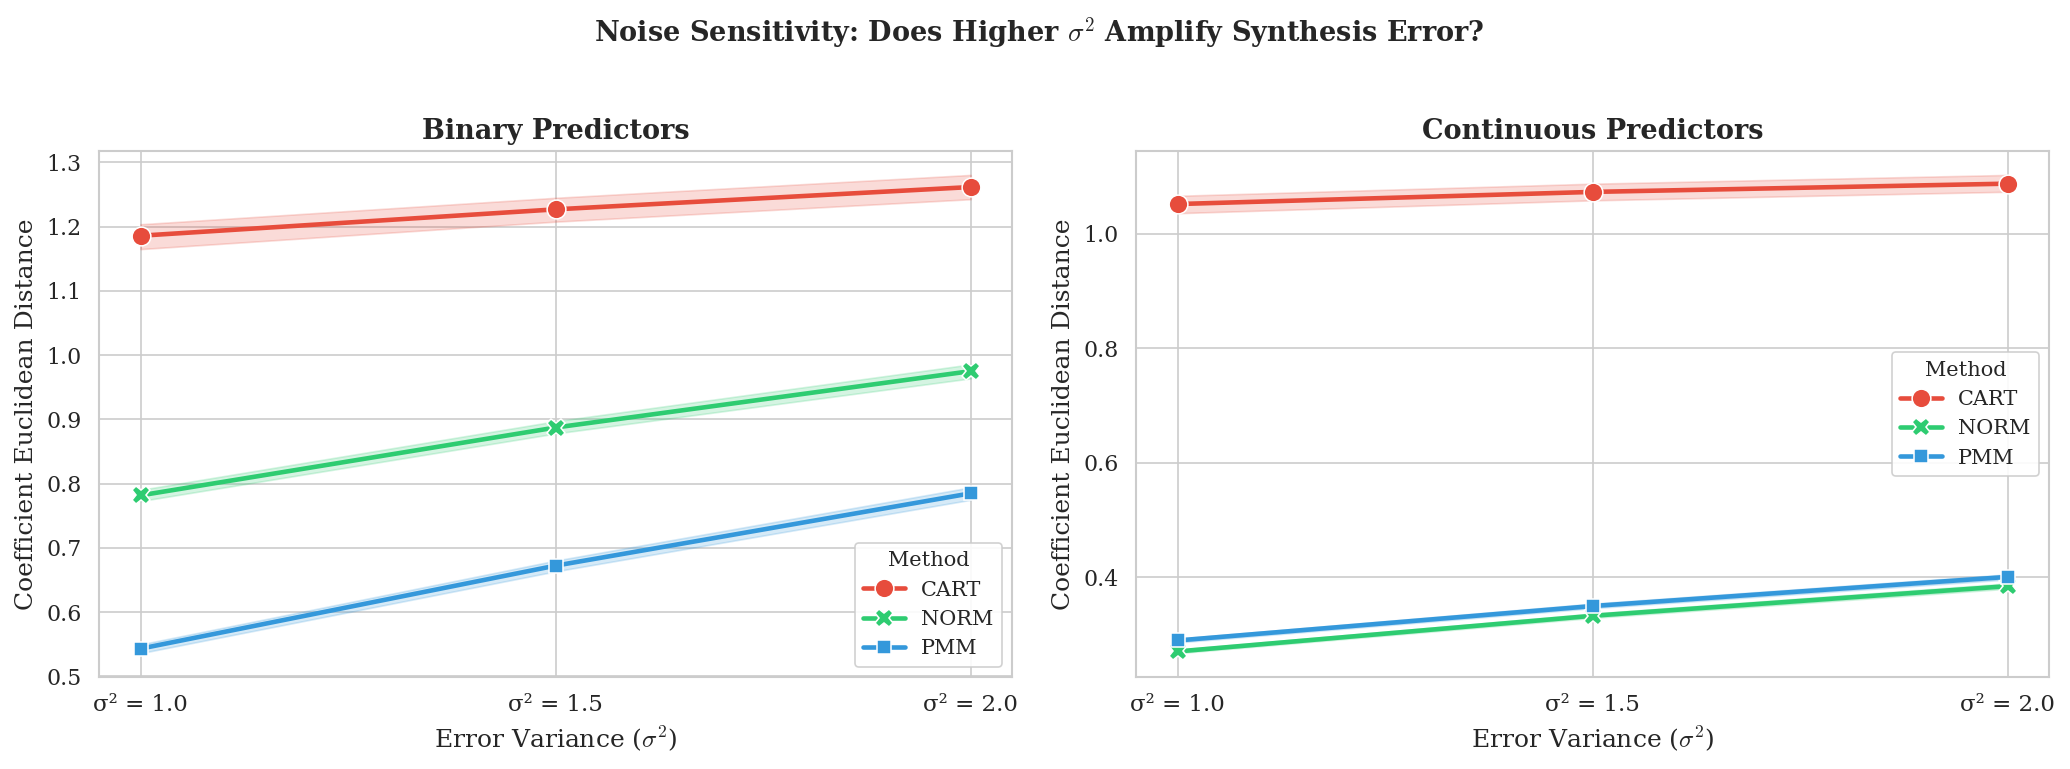

✓ Plot 7 saved.


In [14]:
# ── Plot 7: Noise Sensitivity — Euclidean Distance vs. σ² ───────────────────

plot_df7 = df.dropna(subset=["coef_eucl_dist"]).copy()
plot_df7["Method"]        = plot_df7["method"].str.upper()
plot_df7["Variable Type"] = plot_df7["var_type"].str.capitalize()

n_vtypes = len(VARTYPE_ORDER)
fig, axes = plt.subplots(1, n_vtypes, figsize=(7 * n_vtypes, 5), sharey=False, squeeze=False)
axes = axes.ravel()

for ax, vt in zip(axes, VARTYPE_ORDER):
    subset7 = plot_df7[plot_df7["Variable Type"] == vt]
    sns.lineplot(
        data=subset7,
        x="sigma_2",
        y="coef_eucl_dist",
        hue="Method",
        hue_order=METHOD_ORDER,
        palette=METHOD_PALETTE,
        style="Method",
        markers=True,
        dashes=False,
        errorbar=("ci", 95),
        linewidth=2.2,
        markersize=9,
        ax=ax,
    )
    ax.set_xticks(SIGMA2_VALS)
    ax.set_xticklabels([f"σ² = {v}" for v in SIGMA2_VALS], fontsize=11)
    ax.set_xlabel("Error Variance ($\\sigma^2$)", fontsize=12)
    ax.set_ylabel("Coefficient Euclidean Distance", fontsize=12)
    ax.set_title(f"{vt} Predictors", fontsize=13, fontweight="bold")
    ax.legend(title="Method", fontsize=10, title_fontsize=10, framealpha=0.9)

fig.suptitle(r"Noise Sensitivity: Does Higher $\sigma^2$ Amplify Synthesis Error?",
             fontsize=13, fontweight="bold", y=1.02)

plt.tight_layout()
fig.savefig(os.path.join(fig_dir, "plot7_noise_sensitivity_sigma2.png"))
plt.show()
print("✓ Plot 7 saved.")

---

## Plot 8 — Which Predictors Does CART Fail On? (Per-Predictor Bias Heatmap)

**Research question:** Is CART's coefficient distortion spread evenly across all
predictors, or does it concentrate on specific indices (e.g., large-β predictors)?

For each predictor slot $j = 1 \ldots p$ and each method, the **mean absolute bias**
$$\overline{|\hat{\beta}_{OD,j} - \hat{\beta}_{SD,j}|}$$
is shown as a heatmap (predictors × methods), with separate panels for
`continuous` and `binary` var_type.

**One figure is produced per dimensionality** $p \in \{2, 5, 10\}$, filtering

rows to only those simulated with that $p$ and showing only the $p$ active

predictors. This avoids the artefact where mixing different $p$ values causesslots pull averages down for higher-index predictors.
visually distinct bands (e.g. X1–X2 vs X3–X5 vs X6–X10) because NaN-padded

In [ ]:
# ── Plot 8: Per-predictor mean absolute bias heatmap (one figure per p) ──────
#
# Filtering to rows with the exact p value avoids mixing NaN-padded slots
# from smaller-p simulations, which would otherwise create artificial bands.

_num_key = lambda c: int(c.rsplit("_", 1)[-1])
all_beta_od_s = sorted(
    [c for c in df.columns if c.startswith("beta_od_") and c != "beta_od_0"], key=_num_key
)
all_beta_sd_s = sorted(
    [c for c in df.columns if c.startswith("beta_sd_") and c != "beta_sd_0"], key=_num_key
)

n_vtypes = len(VARTYPE_ORDER)

for p_val in P_VALS:
    # Only keep the first p_val predictor columns (X1 ... Xp)
    beta_od_s = all_beta_od_s[:p_val]
    beta_sd_s = all_beta_sd_s[:p_val]
    n_pred    = p_val

    fig, axes = plt.subplots(1, n_vtypes, figsize=(7 * n_vtypes, max(4, 0.5 * n_pred + 2)),
                             squeeze=False)
    axes = axes.ravel()

    for ax, vt in zip(axes, VAR_TYPES):
        # Filter to rows simulated with this exact p
        sub = df[(df["var_type"] == vt) & (df["p"] == p_val)]
        mat = np.full((n_pred, len(METHODS)), np.nan)

        for mi, m in enumerate(METHODS):
            msub = sub[sub["method"] == m]
            bod  = msub[beta_od_s].values
            bsd  = msub[beta_sd_s].values
            abs_bias = np.abs(bod - bsd)
            mat[:, mi] = np.nanmean(abs_bias, axis=0)

        sns.heatmap(
            mat,
            ax=ax,
            xticklabels=METHOD_ORDER,
            yticklabels=[f"X{j+1}" for j in range(n_pred)],
            cmap="YlOrRd",
            annot=True,
            fmt=".3f",
            linewidths=0.5,
            linecolor="white",
            cbar_kws={"label": r"Mean $|\hat{\beta}_{OD,j} - \hat{\beta}_{SD,j}|$", "shrink": 0.8},
        )
        ax.set_title(f"{vt.capitalize()} Predictors", fontsize=13, fontweight="bold")
        ax.set_xlabel("Synthesis Method", fontsize=12)
        ax.set_ylabel("Predictor", fontsize=12)
        ax.tick_params(axis="y", labelrotation=0)

    fig.suptitle(
        f"Per-Predictor Mean Absolute Bias (p = {p_val}): Where Does Synthesis Error Concentrate?",
        fontsize=13, fontweight="bold", y=1.02,
    )

    plt.tight_layout()
    fname = f"plot8_predictor_bias_heatmap_p{p_val}.png"
    fig.savefig(os.path.join(fig_dir, fname))
    plt.show()
    print(f"\u2713 Plot 8 (p={p_val}) saved as {fname}.")

---

## Plot 9 — Does More Data Improve CI Overlap? (N × CI Overlap %)

**Research question:** Can a simple increase in sample size ($N$) improve how well
the synthetic confidence intervals agree with the original ones?

A point plot with $N \in \{100, 1000\}$ on the x-axis and **CI Overlap %** on the
y-axis, grouped by method and faceted by `var_type`, reveals whether the CI
mismatch is a **finite-sample artefact** (fixable with more data) or a
**systematic structural bias** (persisting regardless of N).

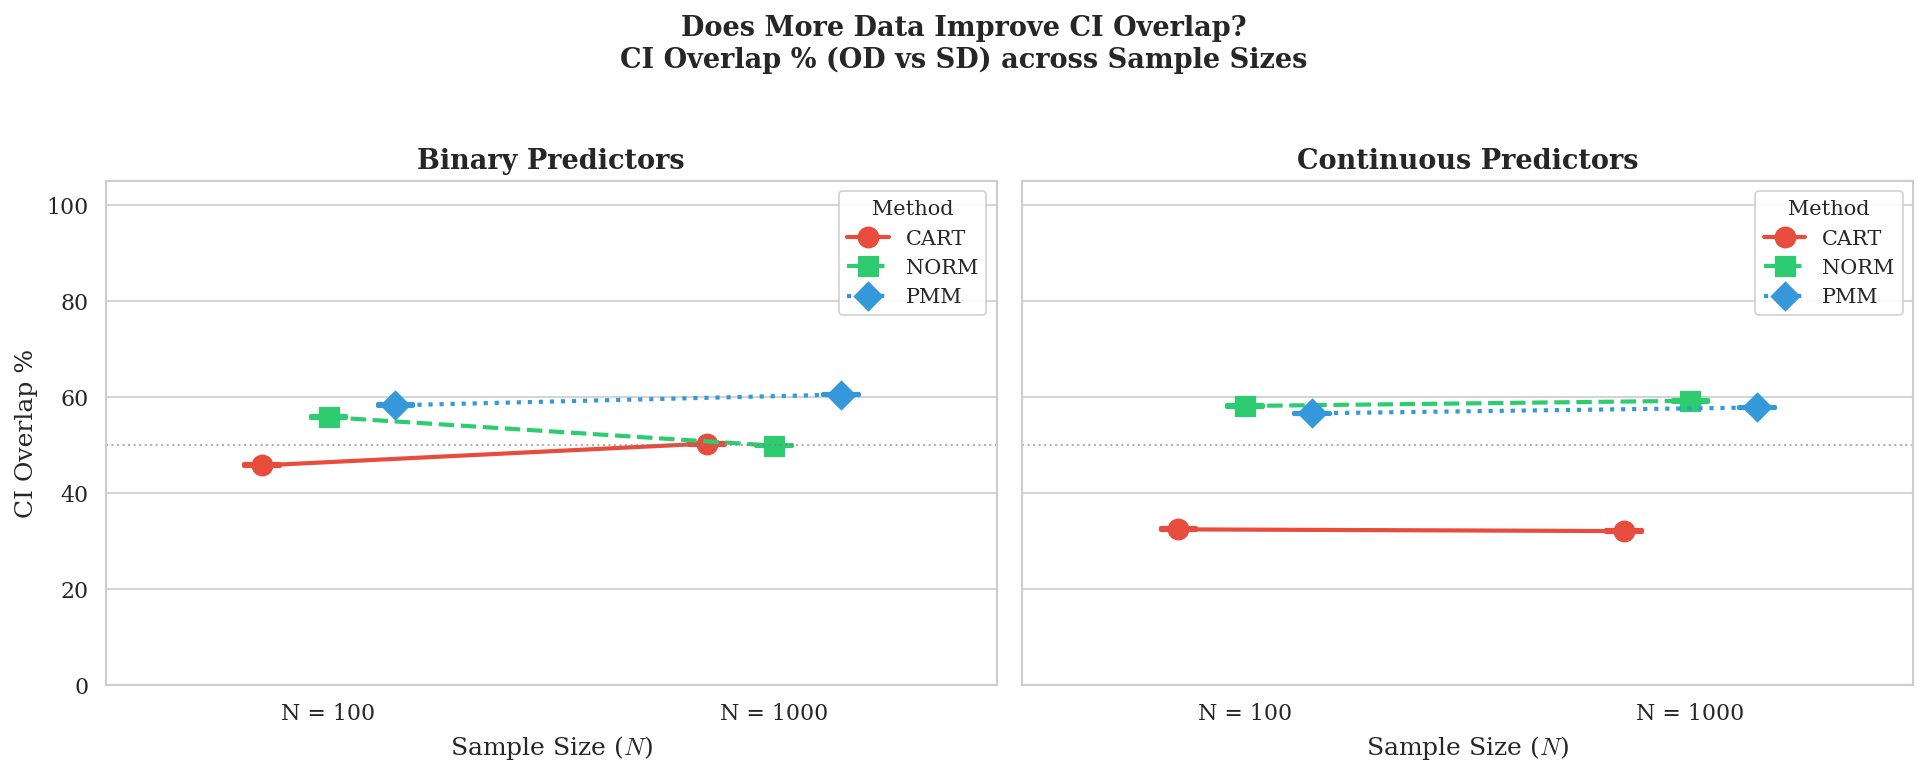

✓ Plot 9 saved.


In [16]:
# ── Plot 9: N × CI Overlap % — does more data improve overlap? ───────────────

cov_df9 = df.dropna(subset=["ci_overlap_pct"]).copy()
cov_df9["Method"]        = cov_df9["method"].str.upper()
cov_df9["Variable Type"] = cov_df9["var_type"].str.capitalize()
cov_df9["N_label"]       = "N = " + cov_df9["N"].astype(str)

N_label_order = [f"N = {n}" for n in N_VALS]

n_vtypes = len(VARTYPE_ORDER)
fig, axes = plt.subplots(1, n_vtypes, figsize=(6.5 * n_vtypes, 5), sharey=True, squeeze=False)
axes = axes.ravel()

for ax, vt in zip(axes, VARTYPE_ORDER):
    subset9 = cov_df9[cov_df9["Variable Type"] == vt]
    sns.pointplot(
        data=subset9,
        x="N_label",
        y="ci_overlap_pct",
        hue="Method",
        hue_order=METHOD_ORDER,
        palette=METHOD_PALETTE,
        order=N_label_order,
        dodge=0.3,
        markers=["o", "s", "D", "^", "v", "P"][:len(METHODS)],
        linestyles=["-", "--", ":", "-.", (0, (3,1,1,1)), (0, (5,2))][:len(METHODS)],
        errorbar=("ci", 95),
        capsize=0.08,
        linewidth=2,
        markersize=9,
        ax=ax,
    )
    ax.axhline(50, color="gray", linestyle=":", linewidth=1, alpha=0.6)
    ax.set_ylim(0, 105)
    ax.set_xlabel("Sample Size ($N$)", fontsize=12)
    ax.set_ylabel("CI Overlap %" if ax == axes[0] else "", fontsize=12)
    ax.set_title(f"{vt} Predictors", fontsize=13, fontweight="bold")
    ax.legend(title="Method", fontsize=10, title_fontsize=10, framealpha=0.9)

fig.suptitle("Does More Data Improve CI Overlap?\n"
             "CI Overlap % (OD vs SD) across Sample Sizes",
             fontsize=13, fontweight="bold", y=1.03)

plt.tight_layout()
fig.savefig(os.path.join(fig_dir, "plot9_N_ci_overlap.png"))
plt.show()
print("✓ Plot 9 saved.")

---

## Plot 10 — Reproduction Fidelity: $\hat{\beta}_{OD}$ vs. $\hat{\beta}_{SD}$ Scatter

**Research question:** Does each synthesis method reproduce the exact coefficient
values, or does it systematically shrink / distort them?

A scatter plot of $\hat{\beta}_{OD,j}$ (x-axis) vs. $\hat{\beta}_{SD,j}$ (y-axis)
for all slopes $j \geq 1$, with one panel per method and colour coding for
`var_type`, directly visualises the magnitude and direction of bias:

* **Perfect synthesis** → all points lie on the `y = x` diagonal.
* **CART's staircase effect** → points cluster around discrete horizontal levels,
  compressed toward zero (the tree's regression-to-mean artefact).
* **NORM / PMM** → points should scatter tightly around the diagonal.


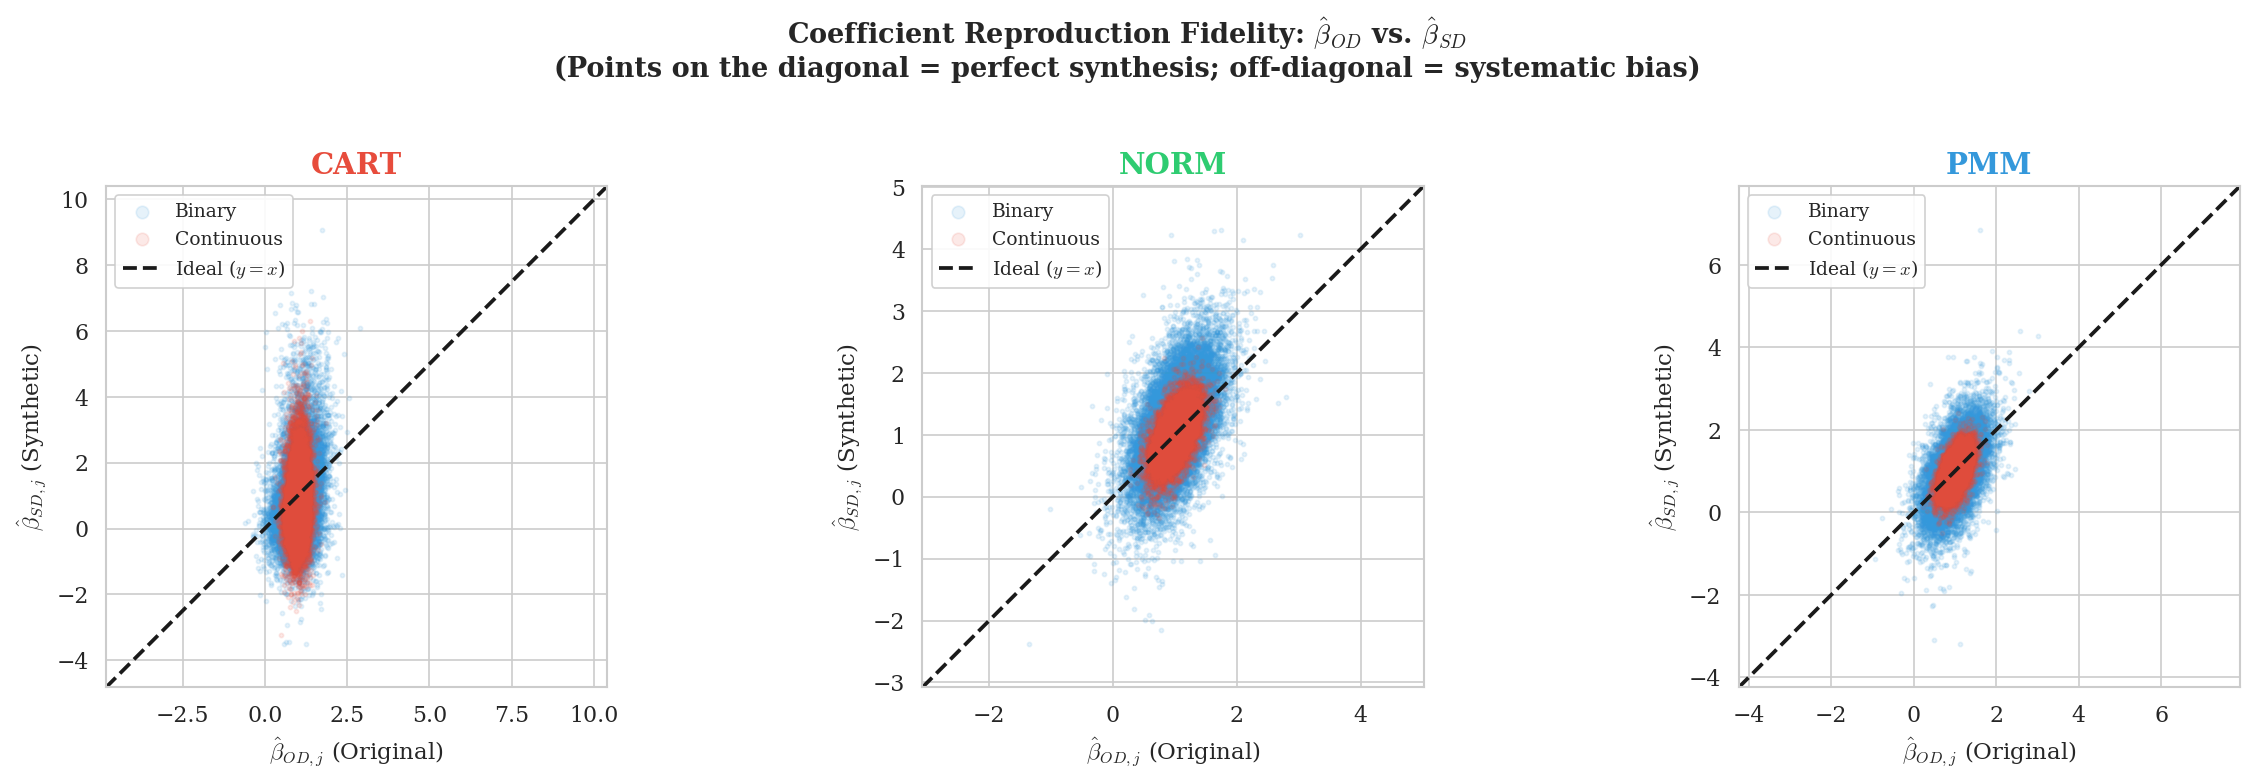

✓ Plot 10 saved.


In [17]:
# ── Plot 10: OD vs SD coefficient scatter (reproduction fidelity) ───────────

beta_od_s10 = [c for c in df.columns if c.startswith("beta_od_") and c != "beta_od_0"]
beta_sd_s10 = [c for c in df.columns if c.startswith("beta_sd_") and c != "beta_sd_0"]

SAMPLE = 20_000
rng    = np.random.default_rng(42)

records = []
for m in METHODS:
    msub = df[df["method"] == m]
    idx  = rng.choice(len(msub), size=min(SAMPLE, len(msub)), replace=False)
    samp = msub.iloc[idx]
    bod  = samp[beta_od_s10].values.ravel()
    bsd  = samp[beta_sd_s10].values.ravel()
    vt   = np.repeat(samp["var_type"].values, len(beta_od_s10))
    keep = ~(np.isnan(bod) | np.isnan(bsd))
    records.append(pd.DataFrame({
        "beta_od": bod[keep],
        "beta_sd": bsd[keep],
        "var_type": vt[keep],
        "Method":  m.upper(),
    }))

scatter_df = pd.concat(records, ignore_index=True)
scatter_df["Variable Type"] = scatter_df["var_type"].str.capitalize()

n_methods = len(METHOD_ORDER)
fig, axes = plt.subplots(1, n_methods, figsize=(5.5 * n_methods, 5), sharey=False, squeeze=False)
axes = axes.ravel()

for ax, m in zip(axes, METHOD_ORDER):
    sdf = scatter_df[scatter_df["Method"] == m]
    for vt in VARTYPE_ORDER:
        vsdf = sdf[sdf["Variable Type"] == vt]
        ax.scatter(
            vsdf["beta_od"], vsdf["beta_sd"],
            c=VARTYPE_PALETTE[vt], alpha=0.12, s=4, rasterized=True, label=vt,
        )
    # y = x reference
    lim_lo = min(ax.get_xlim()[0], ax.get_ylim()[0], sdf["beta_od"].quantile(0.01), sdf["beta_sd"].quantile(0.01))
    lim_hi = max(ax.get_xlim()[1], ax.get_ylim()[1], sdf["beta_od"].quantile(0.99), sdf["beta_sd"].quantile(0.99))
    margin = 0.05 * (lim_hi - lim_lo)
    ref_range = [lim_lo - margin, lim_hi + margin]
    ax.plot(ref_range, ref_range, "k--", linewidth=1.8, label="Ideal ($y=x$)")
    ax.set_xlim(ref_range)
    ax.set_ylim(ref_range)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(m, fontsize=14, fontweight="bold", color=METHOD_PALETTE[m])
    ax.set_xlabel(r"$\hat{\beta}_{OD,j}$ (Original)", fontsize=11)
    ax.set_ylabel(r"$\hat{\beta}_{SD,j}$ (Synthetic)", fontsize=11)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=9, framealpha=0.9,
              markerscale=3)

fig.suptitle(r"Coefficient Reproduction Fidelity: $\hat{\beta}_{OD}$ vs. $\hat{\beta}_{SD}$" + "\n"
             "(Points on the diagonal = perfect synthesis; off-diagonal = systematic bias)",
             fontsize=13, fontweight="bold", y=1.03)

plt.tight_layout()
fig.savefig(os.path.join(fig_dir, "plot10_od_vs_sd_scatter.png"), dpi=300)
plt.show()
print("✓ Plot 10 saved.")

---

## Summary Table

Aggregate all metrics (including CI Overlap %) by **method × var_type** across all scenarios.

In [18]:
# ── Grand summary ───────────────────────────────────────────────────────────
summary = (
    df.dropna(subset=["coef_eucl_dist", "r2_degradation", "sig_agreement_pct"])
      .groupby(["method", "var_type"])
      .agg(
          n = ("coef_eucl_dist", "count"),
          eucl_dist_mean   = ("coef_eucl_dist", "mean"),
          eucl_dist_median = ("coef_eucl_dist", "median"),
          eucl_dist_std    = ("coef_eucl_dist", "std"),
          sig_agree_mean   = ("sig_agreement_pct", "mean"),
          sig_agree_std    = ("sig_agreement_pct", "std"),
          r2_degrad_mean   = ("r2_degradation", "mean"),
          r2_degrad_median = ("r2_degradation", "median"),
          r2_degrad_std    = ("r2_degradation", "std"),
          ci_overlap_mean  = ("ci_overlap_pct", "mean"),
          ci_overlap_median = ("ci_overlap_pct", "median"),
          ci_overlap_std   = ("ci_overlap_pct", "std"),
      )
      .round(4)
)

print("=" * 80)
print("GRAND SUMMARY: Synthesis Method Comparison")
print(f"  Methods: {METHOD_ORDER}  |  Var types: {VARTYPE_ORDER}")
print("=" * 80)
display(summary)

summary.to_csv(os.path.join(result_dir, "evaluation_summary.csv"))
print(f"\n✓ Summary saved to results/evaluation_summary.csv")

GRAND SUMMARY: Synthesis Method Comparison
  Methods: ['CART', 'NORM', 'PMM']  |  Var types: ['Binary', 'Continuous']


n  eucl_dist_mean  eucl_dist_median  eucl_dist_std  \
method var_type                                                             
cart   binary      54000          1.2249            0.7729         1.3288   
       continuous  54000          1.0712            0.7349         1.0366   
norm   binary      54000          0.8813            0.6904         0.6800   
       continuous  54000          0.3289            0.2329         0.2670   
pmm    binary      54000          0.6666            0.4515         0.5958   
       continuous  54000          0.3464            0.2417         0.2782   

                   sig_agree_mean  sig_agree_std  r2_degrad_mean  \
method var_type                                                    
cart   binary             82.9267        24.6469          0.0774   
       continuous         83.1591        26.1195          0.1935   
norm   binary             91.0709        16.5609          0.0430   
       continuous         99.2711         3.9799          0.0240   
pmm    binary             90.8570        16.8878          0.0345   
       continuous         99.0004         4.7630          0.0269   

                   r2_degrad_median  r2_degrad_std  ci_overlap_mean  \
method var_type                                                       
cart   binary                0.0493         0.0785          48.0546   
       continuous            0.1464         0.1651          32.2928   
norm   binary                0.0298         0.0427          52.8622   
       continuous            0.0113         0.0337          58.6941   
pmm    binary                0.0198         0.0412          59.4092   
       continuous            0.0124         0.0389          57.2298   

                   ci_overlap_median  ci_overlap_std  
method var_type                                       
cart   binary                46.3128         17.4212  
       continuous            27.2561         20.3430  
norm   binary                52.7603         13.8494  
       continuous            59.1805         12.9170  
pmm    binary                59.2469         13.7538  
       continuous            58.0937         13.3832


✓ Summary saved to results/evaluation_summary.csv


In [19]:
# ── Key findings for thesis (auto-generated from config) ─────────────────────

print("KEY FINDINGS")
print("=" * 60)

# Per method × var_type: median Euclidean distance
medians = (
    df.dropna(subset=["coef_eucl_dist"])
      .groupby(["method", "var_type"])["coef_eucl_dist"]
      .median()
)

for i, vt in enumerate(VAR_TYPES, 1):
    vt_cap = vt.capitalize()
    print(f"\n{i}. {vt_cap} predictors — median Euclidean distance:")
    vals = {}
    for m in METHODS:
        try:
            val = medians.loc[(m, vt)]
        except KeyError:
            val = float("nan")
        vals[m] = val
        print(f"   {m.upper()}: {val:.3f}", end="")
    print()

    # Compare all pairs: how much worse is each method relative to the best
    best_method = min(vals, key=vals.get)
    best_val = vals[best_method]
    for m in METHODS:
        if m != best_method and best_val > 0:
            print(f"   → {m.upper()} is {vals[m] / best_val:.1f}× relative to {best_method.upper()}")

# Cross var_type comparison for each method
print(f"\n{len(VAR_TYPES) + 1}. Within-method performance ratio across var_types:")
for m in METHODS:
    vt_vals = {}
    for vt in VAR_TYPES:
        try:
            vt_vals[vt] = medians.loc[(m, vt)]
        except KeyError:
            vt_vals[vt] = float("nan")
    worst_vt = max(vt_vals, key=vt_vals.get)
    best_vt  = min(vt_vals, key=vt_vals.get)
    if vt_vals[best_vt] > 0:
        ratio = vt_vals[worst_vt] / vt_vals[best_vt]
        print(f"   {m.upper()}: {ratio:.1f}× worse on {worst_vt} vs {best_vt}")

print("\n✓ Notebook 04 complete.")

KEY FINDINGS

1. Binary predictors — median Euclidean distance:
   CART: 0.773   NORM: 0.690   PMM: 0.452
   → CART is 1.7× relative to PMM
   → NORM is 1.5× relative to PMM

2. Continuous predictors — median Euclidean distance:
   CART: 0.735   NORM: 0.233   PMM: 0.242
   → CART is 3.2× relative to NORM
   → PMM is 1.0× relative to NORM

3. Within-method performance ratio across var_types:
   CART: 1.1× worse on binary vs continuous
   NORM: 3.0× worse on binary vs continuous
   PMM: 1.9× worse on binary vs continuous

✓ Notebook 04 complete.
